### Imports

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from time import time
import joblib
import os

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, f1_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier

SEED = 42

### Load data

In [39]:
stat_df_clahe = pd.read_csv("../data/ml_features/features_stat_clahe.csv")
lbp_df_clahe = pd.read_csv("../data/ml_features/features_lbp_clahe.csv")
hog_df_clahe = pd.read_csv("../data/ml_features/features_hog_clahe.csv")

id_cols = ["image_name", "class"]
df_stat_clahe = stat_df_clahe.copy()
df_lbp_clahe = lbp_df_clahe.copy()
df_hog_clahe = hog_df_clahe.copy()
df_stat_lbp_clahe = df_stat_clahe.merge(df_lbp_clahe, on=id_cols)
df_stat_lbp_hog_clahe = df_stat_clahe.merge(df_lbp_clahe, on=id_cols).merge(df_hog_clahe, on=id_cols)

datasets = {
    "STAT_LBP_CLAHE": df_stat_lbp_clahe,
    "STAT_LBP_HOG_CLAHE": df_stat_lbp_hog_clahe,
}


### UTILS

In [22]:
def prepare_dataset(df):
    df = df.copy()

    X = df.drop(columns=["image_name", "class"])
    y = df["class"]

    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(X.median(numeric_only=True))

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=0.2,
        random_state=SEED,
        stratify=y_encoded
    )

    return X_train, X_test, y_train, y_test, label_encoder


In [24]:

def load_model_and_test_data(model_name):
    if model_name.split("_")[0] == "rf":
        model_path = "random_forest"
    elif model_name.split("_")[0] == "svm":
        model_path = "support_vector_machine"
    elif model_name.split("_")[0] == "xgb":
        model_path = "xgboost"
    elif model_name.split("_")[0] == "knn":
        model_path = "k_nearest_neighbors"
    model = joblib.load(f"../models/{model_path}/{model_name}.pkl")
    if model_name.split("_")[0] == "knn":
        df = datasets["STAT_LBP_CLAHE"]
    else:
        df = datasets["STAT_LBP_HOG_CLAHE"]
    X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df)
    return model, X_test, y_test, label_encoder

In [25]:
def plot_confusion_matrix(model_name, normalize=None):
    model, X_test, y_test, label_encoder = load_model_and_test_data(model_name)

    y_pred = model.predict(X_test)
    
    cm = confusion_matrix(
        y_test,
        y_pred,
        normalize=normalize
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )

    fig, ax = plt.subplots(figsize=(7, 6))

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=45,
        values_format=".2f" if normalize else "d"
    )

    title = f"Confusion Matrix - {model_name}"
    if normalize:
        title = f"Normalized Confusion Matrix - {model_name}"

    plt.title(title)
    plt.tight_layout()
    plt.show()

In [26]:
def print_classification_report(model_name):
    model, X_test, y_test, label_encoder = load_model_and_test_data(model_name)
    
    y_pred = model.predict(X_test)

    print(f"\nRapport de classification pour le modèle {model_name}:\n")
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))

### Cross validation

In [3]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

### SUPPORT VECTOR MACHINE (SVM)

In [40]:
MODEL_DIR = "../models/support_vector_machine"
os.makedirs(MODEL_DIR, exist_ok=True)

svm = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=SEED)),
        ("svm", SVC(
            class_weight="balanced",
            random_state=SEED
        ))
    ])

svm_grid = {
    "svm__C": [0.5, 1, 2.5, 5, 7.5, 10],
    "svm__gamma": ["scale", 0.0005, 0.001, 0.002]
}

In [41]:

svm_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=svm_grid,
    n_iter=24,
    scoring="f1_macro",
    cv=cv,
    random_state=SEED,
    n_jobs=1,
    verbose=10,
    refit=True
)

X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df_stat_lbp_hog_clahe)
svm_search.fit(X_train, y_train)

joblib.dump(svm_search.best_estimator_, f"{MODEL_DIR}/svm_best.pkl")

print()
print("Best parameters :", svm_search.best_params_)
print("Best CV F1 Macro :", svm_search.best_score_)
y_pred = svm_search.best_estimator_.predict(X_test)
f1_macro = f1_score(y_test, y_pred, average="macro")
print("Best model F1 Macro on test set :", f1_macro)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV 1/5; 1/24] START svm__C=0.5, svm__gamma=scale...............................
[CV 1/5; 1/24] END svm__C=0.5, svm__gamma=scale;, score=0.797 total time=  25.0s
[CV 2/5; 1/24] START svm__C=0.5, svm__gamma=scale...............................
[CV 2/5; 1/24] END svm__C=0.5, svm__gamma=scale;, score=0.791 total time=  23.1s
[CV 3/5; 1/24] START svm__C=0.5, svm__gamma=scale...............................
[CV 3/5; 1/24] END svm__C=0.5, svm__gamma=scale;, score=0.804 total time=  19.6s
[CV 4/5; 1/24] START svm__C=0.5, svm__gamma=scale...............................
[CV 4/5; 1/24] END svm__C=0.5, svm__gamma=scale;, score=0.782 total time=  19.1s
[CV 5/5; 1/24] START svm__C=0.5, svm__gamma=scale...............................
[CV 5/5; 1/24] END svm__C=0.5, svm__gamma=scale;, score=0.804 total time=  19.5s
[CV 1/5; 2/24] START svm__C=0.5, svm__gamma=0.0005..............................
[CV 1/5; 2/24] END svm__C=0.5, svm__gamma=0.000

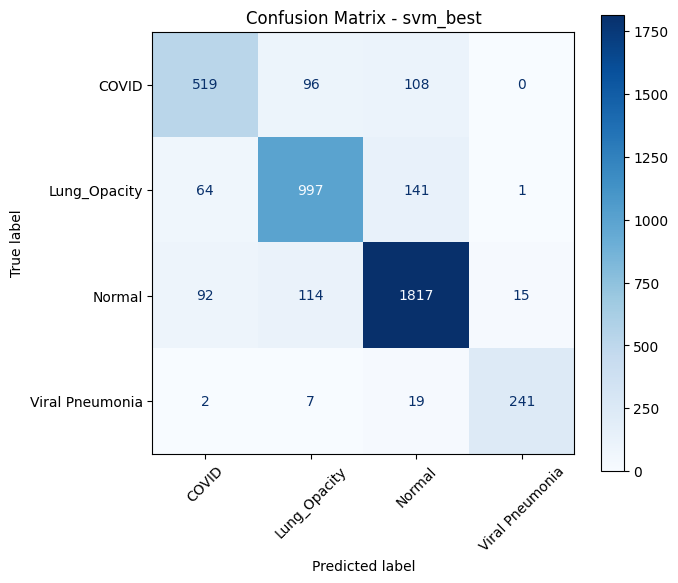


Rapport de classification pour le modèle svm_best:

                 precision    recall  f1-score   support

          COVID       0.77      0.72      0.74       723
   Lung_Opacity       0.82      0.83      0.82      1203
         Normal       0.87      0.89      0.88      2038
Viral Pneumonia       0.94      0.90      0.92       269

       accuracy                           0.84      4233
      macro avg       0.85      0.83      0.84      4233
   weighted avg       0.84      0.84      0.84      4233



In [42]:
model_name = "svm_best"
plot_confusion_matrix(model_name)
print_classification_report(model_name)

### K-NEAREST NEIGHBORS (KNN)

In [43]:
MODEL_DIR = "../models/k_nearest_neighbors"
os.makedirs(MODEL_DIR, exist_ok=True)

knn =Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier())
    ])

knn_grid = {
    "knn__n_neighbors": [4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [0.5, 1, 2, 3, 4],
}

In [44]:

knn_search = RandomizedSearchCV(
    estimator=knn,
    param_distributions=knn_grid,
    n_iter=100,
    scoring="f1_macro",
    cv=cv,
    random_state=SEED,
    n_jobs=1,
    verbose=10,
    refit=True
)

X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df_stat_lbp_clahe)
knn_search.fit(X_train, y_train)

joblib.dump(knn_search.best_estimator_, f"{MODEL_DIR}/knn_best.pkl")

print()
print("Best parameters :", knn_search.best_params_)
print("Best CV F1 Macro :", knn_search.best_score_)
y_pred = knn_search.best_estimator_.predict(X_test)
f1_macro = f1_score(y_test, y_pred, average="macro")
print("Best model F1 Macro on test set :", f1_macro)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV 1/5; 1/100] START knn__n_neighbors=4, knn__p=0.5, knn__weights=uniform......


d:\Documents\Alternance MLE\projet\2-DS\Analysis-of-COVID-19-Chest-X-rays\.venv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(


[CV 1/5; 1/100] END knn__n_neighbors=4, knn__p=0.5, knn__weights=uniform;, score=0.703 total time=  10.1s
[CV 2/5; 1/100] START knn__n_neighbors=4, knn__p=0.5, knn__weights=uniform......


d:\Documents\Alternance MLE\projet\2-DS\Analysis-of-COVID-19-Chest-X-rays\.venv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(


[CV 2/5; 1/100] END knn__n_neighbors=4, knn__p=0.5, knn__weights=uniform;, score=0.724 total time=   9.6s
[CV 3/5; 1/100] START knn__n_neighbors=4, knn__p=0.5, knn__weights=uniform......


...

[CV 3/5; 92/100] END knn__n_neighbors=13, knn__p=0.5, knn__weights=distance;, score=0.739 total time=   9.6s
[CV 4/5; 92/100] START knn__n_neighbors=13, knn__p=0.5, knn__weights=distance...


d:\Documents\Alternance MLE\projet\2-DS\Analysis-of-COVID-19-Chest-X-rays\.venv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(


[CV 4/5; 92/100] END knn__n_neighbors=13, knn__p=0.5, knn__weights=distance;, score=0.722 total time=   9.5s
[CV 5/5; 92/100] START knn__n_neighbors=13, knn__p=0.5, knn__weights=distance...


d:\Documents\Alternance MLE\projet\2-DS\Analysis-of-COVID-19-Chest-X-rays\.venv\Lib\site-packages\sklearn\neighbors\_base.py:661: UserWarning: Mind that for 0 < p < 1, Minkowski metrics are not distance metrics. Continuing the execution with `algorithm='brute'`.
  warnings.warn(


[CV 5/5; 92/100] END knn__n_neighbors=13, knn__p=0.5, knn__weights=distance;, score=0.724 total time=   9.5s
[CV 1/5; 93/100] START knn__n_neighbors=13, knn__p=1, knn__weights=uniform......
[CV 1/5; 93/100] END knn__n_neighbors=13, knn__p=1, knn__weights=uniform;, score=0.731 total time=   0.3s
[CV 2/5; 93/100] START knn__n_neighbors=13, knn__p=1, knn__weights=uniform......
[CV 2/5; 93/100] END knn__n_neighbors=13, knn__p=1, knn__weights=uniform;, score=0.734 total time=   0.3s
[CV 3/5; 93/100] START knn__n_neighbors=13, knn__p=1, knn__weights=uniform......
[CV 3/5; 93/100] END knn__n_neighbors=13, knn__p=1, knn__weights=uniform;, score=0.725 total time=   0.3s
[CV 4/5; 93/100] START knn__n_neighbors=13, knn__p=1, knn__weights=uniform......
[CV 4/5; 93/100] END knn__n_neighbors=13, knn__p=1, knn__weights=uniform;, score=0.720 total time=   0.3s
[CV 5/5; 93/100] START knn__n_neighbors=13, knn__p=1, knn__weights=uniform......
[CV 5/5; 93/100] END knn__n_neighbors=13, knn__p=1, knn__weigh

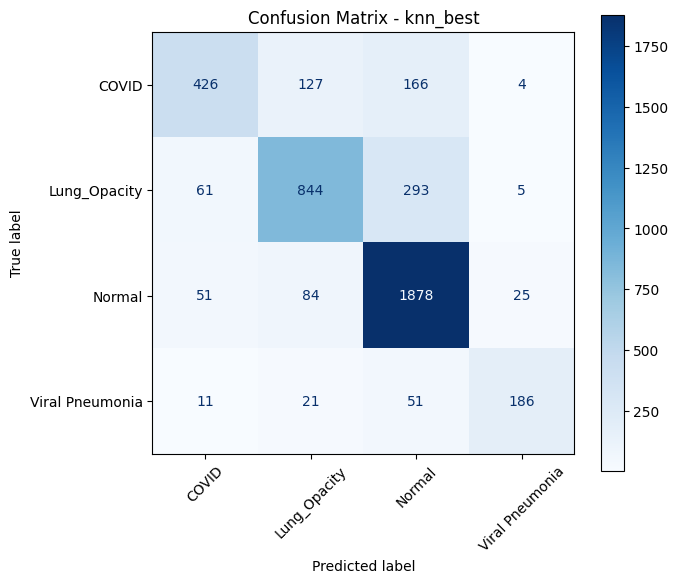


Rapport de classification pour le modèle knn_best:

                 precision    recall  f1-score   support

          COVID       0.78      0.59      0.67       723
   Lung_Opacity       0.78      0.70      0.74      1203
         Normal       0.79      0.92      0.85      2038
Viral Pneumonia       0.85      0.69      0.76       269

       accuracy                           0.79      4233
      macro avg       0.80      0.73      0.75      4233
   weighted avg       0.79      0.79      0.78      4233



In [45]:
model_name = "knn_best"
plot_confusion_matrix(model_name)
print_classification_report(model_name)

### RANDOM FOREST (RF)

In [ ]:

# MODEL_DIR = "../models/random_forest"
# os.makedirs(MODEL_DIR, exist_ok=True)

# # rf = RandomForestClassifier(
# #     random_state=SEED
# # )

# rf = Pipeline([
#     ("scaler", StandardScaler()),
#     ("pca", PCA(n_components=0.95, random_state=SEED)),
#     ("rf", RandomForestClassifier(
#         random_state=SEED
#     ))
# ])

# rf_grid = {
#     "rf__n_estimators": [300, 400, 500],
#     "rf__max_depth": [30, 40, None],
#     "rf__min_samples_split": [2, 3],
#     "rf__min_samples_leaf": [1, 2],
#     "rf__max_features": ["sqrt"],
#     "rf__bootstrap": [True, False],
#     "rf__criterion": ["gini", "entropy", "log_loss"],
#     "rf__class_weight": [None, "balanced", "balanced_subsample"]
# }

In [ ]:
# rf_search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=rf_grid,
#     n_iter=120,
#     scoring="f1_macro",
#     cv=cv,
#     random_state=SEED,
#     n_jobs=1,
#     verbose=10,
#     refit=True
# )

# X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df_stat_lbp_hog_clahe)
# rf_search.fit(X_train, y_train)

# joblib.dump(rf_search.best_estimator_, f"{MODEL_DIR}/rf_best.pkl")

# print()
# print("Best parameters :", rf_search.best_params_)
# print("Best CV F1 Macro :", rf_search.best_score_)
# y_pred = rf_search.best_estimator_.predict(X_test)
# f1_macro = f1_score(y_test, y_pred, average="macro")
# print("Best model F1 Macro on test set :", f1_macro)

In [ ]:
# model_name = "rf_best"
# plot_confusion_matrix(model_name)
# print_classification_report(model_name)

### XGBOOST (XGB)

In [55]:
MODEL_DIR = "../models/xgboost"
os.makedirs(MODEL_DIR, exist_ok=True)

xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1,
    device="cuda",
    tree_method="hist"
)

# xgb_grid = {
#     "n_estimators":[200, 400, 600],
#     "learning_rate":[0.01, 0.05, 0.1],
#     "max_depth":[3, 5, 7],
#     "subsample":[0.8, 1.0],
#     "colsample_bytree":[0.8, 1.0]
# }

xgb_grid = {
    "n_estimators": [500, 600, 700],
    "learning_rate": [0.08, 0.10, 0.12],
    "max_depth": [4, 5, 6],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3]
}

In [56]:

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_grid,
    n_iter=108,
    scoring="f1_macro",
    cv=cv,
    random_state=SEED,
    n_jobs=1,
    verbose=10,
    refit=True
)

X_train, X_test, y_train, y_test, label_encoder = prepare_dataset(df_stat_lbp_hog_clahe)
xgb_search.fit(X_train, y_train)

joblib.dump(xgb_search.best_estimator_, f"{MODEL_DIR}/xgb_best.pkl")

print()
print("Best parameters :", xgb_search.best_params_)
print("Best CV F1 Macro :", xgb_search.best_score_)
y_pred = xgb_search.best_estimator_.predict(X_test)
f1_macro = f1_score(y_test, y_pred, average="macro")
print("Best model F1 Macro on test set :", f1_macro)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
[CV 1/5; 1/108] START colsample_bytree=0.8, gamma=0.3, learning_rate=0.12, max_depth=5, min_child_weight=1, n_estimators=500
[CV 1/5; 1/108] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.12, max_depth=5, min_child_weight=1, n_estimators=500;, score=0.845 total time=  15.3s
[CV 2/5; 1/108] START colsample_bytree=0.8, gamma=0.3, learning_rate=0.12, max_depth=5, min_child_weight=1, n_estimators=500
[CV 2/5; 1/108] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.12, max_depth=5, min_child_weight=1, n_estimators=500;, score=0.859 total time=  19.4s
[CV 3/5; 1/108] START colsample_bytree=0.8, gamma=0.3, learning_rate=0.12, max_depth=5, min_child_weight=1, n_estimators=500
[CV 3/5; 1/108] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.12, max_depth=5, min_child_weight=1, n_estimators=500;, score=0.851 total time=  21.6s
[CV 4/5; 1/108] START colsample_bytree=0.8, gamma=0.3, learning_rate=0.12, max_depth=5, min_ch

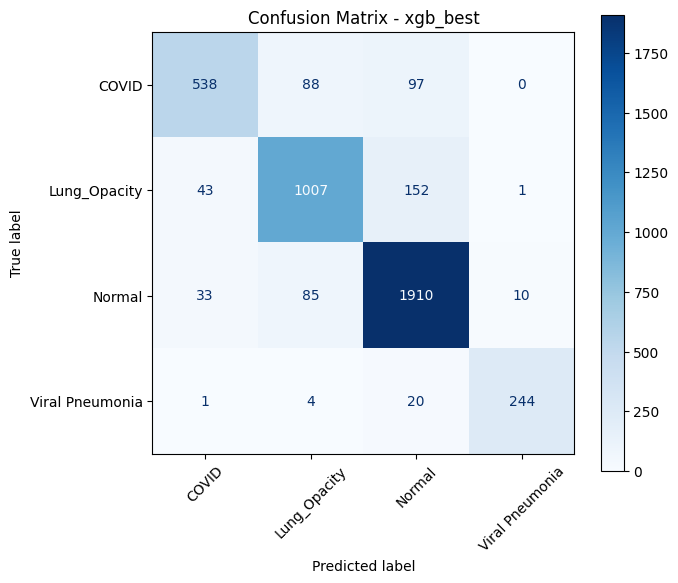


Rapport de classification pour le modèle xgb_best:

                 precision    recall  f1-score   support

          COVID       0.87      0.74      0.80       723
   Lung_Opacity       0.85      0.84      0.84      1203
         Normal       0.88      0.94      0.91      2038
Viral Pneumonia       0.96      0.91      0.93       269

       accuracy                           0.87      4233
      macro avg       0.89      0.86      0.87      4233
   weighted avg       0.87      0.87      0.87      4233



In [57]:
model_name = "xgb_best"
plot_confusion_matrix(model_name)
print_classification_report(model_name)